# EEG_07f — Preprocessing: Graph & Hypergraph Tensors

Sostituisce EEG_07e. Per ogni trial CSV di Paolo produce:
- `graphs/`             → grafo non-pruned (edge_index + edge_attr)
- `graphs_pruned/`      → grafo con consensus pruning
- `hypergraphs/`        → ipergrafo non-pruned (incidence matrix H)
- `hypergraphs_pruned/` → ipergrafo con consensus pruning

**Sorgente dati**: `data/raw_csv/training_set/PXXX_SYYY/word_img.csv`  
**Shape CSV**: (61 canali × 384 campioni), no header, float32  
**Paradigma**: 1 file .pt per trial — mai file monolitici


In [2]:
import json
import logging
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from scipy.signal import hilbert
from tqdm.auto import tqdm


In [3]:
# ============================================================
# CONFIG — modifica qui, poi Kernel → Restart & Run All
# ============================================================

# Metriche per cui costruire i grafi — una directory di output per metrica.
# Ablation: metti tutte e 5 per confronto completo.
METRICS = ["pcc", "abs_pcc", "im_pcc", "wpli", "plv"]

# Metriche usate per il consensus pruning (indipendente da METRICS)
CONSENSUS_METRICS = ["wpli", "plv", "abs_pcc", "im_pcc"]

# Soglia consensus: None = maggioranza (ceil(n/2)); int = fisso
CONSENSUS_K = None

# Top-X% per metric: arco significativo se |valore| >= percentile X
EDGE_THRESHOLD_PCT = 80     # top 20% archi per metrica

# k vicini per iperedge (costruzione matrice di incidenza H)
K_HYPEREDGE = 6

# Salta trial già processati (utile per resume dopo crash)
OVERWRITE = False


In [4]:
# ============================================================
# SETUP — path, logging, mapping parola → label_idx
# ============================================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("eeg07f")

# Root di progetto
project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve(),
)

CSV_ROOT = project_root / "data" / "raw_csv" / "training_set"
DATA_OUT = project_root / "data"   # graphs_{metric}/ e graphs_pruned_{metric}/ qui sotto

assert CSV_ROOT.exists(), f"CSV_ROOT non trovato: {CSV_ROOT}"
log.info(f"project_root : {project_root}")
log.info(f"CSV_ROOT     : {CSV_ROOT}")

# word → label_idx
_label2idx_path = project_root / "configs" / "label_schemes" / "label2idx.json"
word2label: dict = json.loads(_label2idx_path.read_text())
log.info(f"Vocabolario  : {len(word2label)} parole")

# Verifica metriche configurate
_VALID_METRICS = {"pcc", "abs_pcc", "im_pcc", "wpli", "plv"}
assert all(m in _VALID_METRICS for m in METRICS), f"Metrica non valida in METRICS"
assert all(m in _VALID_METRICS for m in CONSENSUS_METRICS), f"Metrica non valida in CONSENSUS_METRICS"

_eff_k = CONSENSUS_K if CONSENSUS_K is not None else __import__("math").ceil(len(CONSENSUS_METRICS) / 2)
log.info(f"METRICS      : {METRICS}")
log.info(f"Consensus    : {CONSENSUS_METRICS}  k={_eff_k}/{len(CONSENSUS_METRICS)}")
log.info(f"Threshold    : percentile {EDGE_THRESHOLD_PCT} → top {100-EDGE_THRESHOLD_PCT:.0f}%")


20:45:16  INFO      project_root : /home/daniele_u/miralis-hypergraph-imagined-speech
20:45:16  INFO      CSV_ROOT     : /home/daniele_u/miralis-hypergraph-imagined-speech/data/raw_csv/training_set
20:45:16  INFO      Vocabolario  : 110 parole
20:45:16  INFO      METRICS      : ['pcc', 'abs_pcc', 'im_pcc', 'wpli', 'plv']
20:45:16  INFO      Consensus    : ['wpli', 'plv', 'abs_pcc', 'im_pcc']  k=2/4
20:45:16  INFO      Threshold    : percentile 80 → top 20%


In [5]:
# ============================================================
# METRICHE DI CONNETTIVITÀ
# Ogni funzione riceve x: (N_ch, N_samples) float32
# Restituisce matrice (N, N) float32, diagonale = 0
# ============================================================

def _pcc(x: np.ndarray) -> np.ndarray:
    """Pearson Correlation Coefficient."""
    mat = np.corrcoef(x).astype(np.float32)
    np.fill_diagonal(mat, 0.0)
    return mat


def _abs_pcc(x: np.ndarray) -> np.ndarray:
    """Valore assoluto del PCC."""
    return np.abs(_pcc(x))


def _im_pcc(x: np.ndarray) -> np.ndarray:
    """
    Parte immaginaria della coerenza complessa (imaginary coherence).
    Basata sull'analytic signal via Hilbert — insensibile alla conduzione
    di volume (componenti a zero-lag si cancellano).
    Ref: Nolte et al. 2004 (Clin Neurophysiol).
    """
    z = hilbert(x, axis=1)              # segnale analitico (N, T)
    N, T = z.shape
    # Matrice di cross-correlazione normalizzata
    cross = (z @ z.conj().T) / T        # (N, N), unnormalised
    norms = np.sqrt(np.mean(np.abs(z) ** 2, axis=1))   # (N,)
    norm_mat = np.outer(norms, norms) + 1e-12
    coherency = cross / norm_mat        # coerenza complessa (N, N)
    mat = np.imag(coherency).astype(np.float32)
    np.fill_diagonal(mat, 0.0)
    return mat


def _wpli(x: np.ndarray) -> np.ndarray:
    """
    Weighted Phase Lag Index.
    wPLI[i,j] = |E[Im(Sxy)]| / E[|Im(Sxy)|]
    Ref: Vinck et al. 2011 (NeuroImage).
    """
    z = hilbert(x, axis=1)              # (N, T) analytic signal
    N = x.shape[0]
    wpli = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        cross_im = np.imag(z[i] * np.conj(z))  # (N, T)
        num = np.abs(np.mean(cross_im, axis=1))
        den = np.mean(np.abs(cross_im), axis=1) + 1e-10
        wpli[i] = (num / den).astype(np.float32)
    np.fill_diagonal(wpli, 0.0)
    return wpli


def _plv(x: np.ndarray) -> np.ndarray:
    """
    Phase Locking Value.
    PLV[i,j] = |mean_t( exp(i*(phi_i - phi_j)) )|
    Ref: Lachaux et al. 1999 (Human Brain Mapping).
    """
    z = hilbert(x, axis=1)              # (N, T) analytic signal
    phases = z / (np.abs(z) + 1e-10)   # (N, T) unit complex
    N = x.shape[0]
    plv = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        cross = phases[i] * np.conj(phases)     # (N, T)
        plv[i] = np.abs(np.mean(cross, axis=1)).astype(np.float32)
    np.fill_diagonal(plv, 0.0)
    return plv


_METRIC_FNS = {
    "pcc":     _pcc,
    "abs_pcc": _abs_pcc,
    "im_pcc":  _im_pcc,
    "wpli":    _wpli,
    "plv":     _plv,
}


def compute_metric(x: np.ndarray, metric: str) -> np.ndarray:
    """Calcola metrica di connettività per un singolo trial."""
    return _METRIC_FNS[metric](x)


print("Metriche OK:", list(_METRIC_FNS.keys()))


Metriche OK: ['pcc', 'abs_pcc', 'im_pcc', 'wpli', 'plv']


In [6]:
# ============================================================
# CONSENSUS PRUNING — majority vote su metriche multiple
# ============================================================

def _significance_mask(mat: np.ndarray, threshold_pct: float) -> np.ndarray:
    """
    Maschera binaria: 1 se |valore| >= percentile threshold_pct dei valori
    off-diagonali. Funziona su metriche sia positive che signed.

    Args:
        mat:           (N, N) matrice di connettività
        threshold_pct: percentile (es. 80 → soglia al p80, top 20% archi)

    Returns: (N, N) bool array, diagonale sempre False
    """
    N = mat.shape[0]
    vals = np.abs(mat)
    np.fill_diagonal(vals, 0.0)
    off_diag = vals[~np.eye(N, dtype=bool)]
    thr = np.percentile(off_diag, threshold_pct)
    mask = (vals >= thr)
    np.fill_diagonal(mask, False)
    return mask


def compute_consensus_mask(
    x: np.ndarray,
    consensus_metrics: list[str],
    threshold_pct: float,
    k: int | None,
) -> np.ndarray:
    """
    Consensus mask: majority vote su più metriche.

    Per ogni metrica in consensus_metrics:
      1. Calcola matrice di connettività
      2. Applica soglia al percentile threshold_pct → maschera binaria

    Somma le maschere → consensus_score[i,j] = n. metriche che concordano.
    Tieni solo gli archi con consensus_score >= k.

    Args:
        x:                 (N, T) trial EEG normalizzato
        consensus_metrics: lista di nomi metrica
        threshold_pct:     soglia per singola metrica (percentile)
        k:                 soglia minima consensus (None = ceil(n/2))

    Returns: (N, N) bool array — True = arco sopravvive al pruning
    """
    n_metrics = len(consensus_metrics)
    eff_k = math.ceil(n_metrics / 2) if k is None else k
    N = x.shape[0]
    vote_sum = np.zeros((N, N), dtype=np.int8)

    for metric in consensus_metrics:
        mat  = compute_metric(x, metric)
        mask = _significance_mask(mat, threshold_pct)
        vote_sum += mask.astype(np.int8)

    consensus = vote_sum >= eff_k
    np.fill_diagonal(consensus, False)
    return consensus


print("Consensus masking OK")


Consensus masking OK


In [7]:
# ============================================================
# COSTRUTTORI GRAFO E IPERGRAFO
# ============================================================

def _adj_to_sparse(adj: np.ndarray):
    """
    Converte matrice di adiacenza (N, N) in edge_index [2, E] + edge_attr [E].
    """
    rows, cols = np.where(adj != 0.0)
    edge_index = torch.tensor(np.stack([rows, cols], axis=0), dtype=torch.long)
    edge_attr  = torch.tensor(adj[rows, cols], dtype=torch.float32)
    return edge_index, edge_attr


def build_graph_dict(
    x_norm: np.ndarray,
    metric: str,
    label: int,
    meta: dict,
    consensus_mask: np.ndarray | None = None,
) -> dict:
    """
    Costruisce dizionario PyG-compatibile per un singolo trial.

    Args:
        x_norm:         (N, T) EEG normalizzato per-canale
        metric:         nome metrica per pesi archi
        label:          class label intero
        meta:           dizionario metadati trial
        consensus_mask: (N, N) bool — se None, nessun pruning

    Returns dict con chiavi: edge_index, edge_attr, x, adj, y, meta
    """
    adj_full = compute_metric(x_norm, metric)           # (N, N) float

    if consensus_mask is not None:
        adj_eff = adj_full * consensus_mask.astype(np.float32)
    else:
        adj_eff = adj_full

    edge_index, edge_attr = _adj_to_sparse(adj_eff)

    return {
        "edge_index": edge_index,                                   # [2, E]
        "edge_attr":  edge_attr,                                    # [E]
        "x":          torch.tensor(x_norm, dtype=torch.float32),   # [N, T]
        "adj":        torch.tensor(adj_eff, dtype=torch.float32),  # [N, N]
        "y":          torch.tensor(label,  dtype=torch.long),
        "meta":       meta,
    }


def _build_incidence_matrix(adj: np.ndarray, k: int) -> np.ndarray:
    """
    Costruisce matrice di incidenza H di shape (N_nodes, N_hyperedges).

    Ogni nodo i genera un iperedge che include se stesso + i top-k vicini
    secondo la matrice adj. Se adj è già pruned, i vicini disconnessi
    vengono esclusi naturalmente.

    H[n, e] = 1 se il nodo n appartiene all'iperedge e, altrimenti 0.
    """
    N = adj.shape[0]
    H = np.zeros((N, N), dtype=np.float32)

    for i in range(N):
        row = adj[i].copy()
        row[i] = 0.0                                    # escludi self
        sorted_neighbors = np.argsort(row)[::-1]        # decrescente per valore
        connected = sorted_neighbors[row[sorted_neighbors] > 0]   # solo archi esistenti
        top_k_neigh = connected[:k]                     # al più k vicini
        members = np.concatenate([[i], top_k_neigh])
        H[members, i] = 1.0

    return H


def build_hypergraph_dict(
    x_norm: np.ndarray,
    metric: str,
    k_hyperedge: int,
    label: int,
    meta: dict,
    consensus_mask: np.ndarray | None = None,
) -> dict:
    """
    Costruisce dizionario ipergrafo per un singolo trial.
    Usa la matrice di incidenza H invece di edge_index/edge_attr.

    Un iperedge è definito da un nodo centrale + i suoi top-k vicini.
    Se consensus_mask è fornita, solo gli archi che superano il pruning
    contribuiscono alla membership dell'iperedge.
    """
    adj_full = compute_metric(x_norm, metric)

    if consensus_mask is not None:
        adj_eff = adj_full * consensus_mask.astype(np.float32)
    else:
        adj_eff = adj_full

    H = _build_incidence_matrix(adj_eff, k=k_hyperedge)

    return {
        "H":    torch.tensor(H,        dtype=torch.float32),   # [N, N_hyperedges]
        "x":    torch.tensor(x_norm,   dtype=torch.float32),   # [N, T]
        "adj":  torch.tensor(adj_eff,  dtype=torch.float32),   # [N, N]
        "y":    torch.tensor(label,    dtype=torch.long),
        "meta": meta,
    }


print("Graph & hypergraph builders OK")


Graph & hypergraph builders OK


In [8]:
# ============================================================
# I/O — caricamento CSV, normalizzazione, salvataggio .pt
# ============================================================

def load_trial(csv_path: Path) -> np.ndarray:
    """
    Carica un trial CSV di Paolo.
    Shape attesa: (61, 384) — righe=canali, colonne=campioni temporali.
    Nessun header, valori float separati da virgola.
    """
    x = pd.read_csv(csv_path, header=None).values.astype(np.float32)
    if x.ndim != 2:
        raise ValueError(f"Shape inattesa {x.shape} in {csv_path}")
    return x  # (N_ch, N_samples)


def normalize_trial(x: np.ndarray) -> np.ndarray:
    """
    Z-score per-canale: (x - mean) / std su asse temporale.
    Clip std a 1e-6 per evitare divisione per zero.
    """
    mean = x.mean(axis=1, keepdims=True)
    std  = x.std(axis=1,  keepdims=True).clip(1e-6)
    return (x - mean) / std


def save_pt(data: dict, path: Path) -> None:
    """Salva dizionario come .pt, crea le cartelle necessarie."""
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(data, path)


print("I/O utilities OK")


I/O utilities OK


In [9]:
# ============================================================
# MAIN LOOP — per sessione → per trial → per metrica
# Consensus mask calcolata UNA VOLTA per trial (non dipende da METRICS)
# ============================================================

def _out_path(base: Path, metric: str, pruned: bool,
              subj_id: int, sess_id: int, trial_idx: int) -> Path:
    """graphs_{metric}/ o graphs_pruned_{metric}/ / P{xxx}_S{yyy}/trial_{zzz}.pt"""
    kind   = "graphs_pruned" if pruned else "graphs"
    folder = f"P{subj_id:03d}_S{sess_id:03d}"
    return DATA_OUT / f"{kind}_{metric}" / folder / f"trial_{trial_idx:03d}.pt"


def _out_path_hg(base: Path, metric: str, pruned: bool,
                 subj_id: int, sess_id: int, trial_idx: int) -> Path:
    kind   = "hypergraphs_pruned" if pruned else "hypergraphs"
    folder = f"P{subj_id:03d}_S{sess_id:03d}"
    return DATA_OUT / f"{kind}_{metric}" / folder / f"trial_{trial_idx:03d}.pt"


def process_session(session_dir: Path, subj_id: int, sess_id: int) -> tuple[int, int]:
    """Processa tutti i trial di una sessione per tutte le METRICS."""
    csv_files = sorted(session_dir.glob("*_img.csv"))
    n_proc = n_skip = 0

    for trial_idx, csv_path in enumerate(
        tqdm(csv_files, desc=f"  P{subj_id:03d}_S{sess_id:03d}", leave=False)
    ):
        word = csv_path.stem.replace("_img", "")
        if word not in word2label:
            n_skip += 1
            continue

        label = word2label[word]

        # Controlla se TUTTI i file di output esistono già
        all_exist = all(
            _out_path(DATA_OUT, m, pruned, subj_id, sess_id, trial_idx).exists() and
            _out_path_hg(DATA_OUT, m, pruned, subj_id, sess_id, trial_idx).exists()
            for m in METRICS for pruned in [False, True]
        )
        if not OVERWRITE and all_exist:
            n_proc += 1
            continue

        # Carica e normalizza (una sola volta per trial)
        x_norm = normalize_trial(load_trial(csv_path))  # (61, 384)

        # Consensus mask — calcolata ONCE per trial, usata da tutte le metriche
        cons_mask = compute_consensus_mask(
            x_norm, CONSENSUS_METRICS, EDGE_THRESHOLD_PCT, CONSENSUS_K
        )

        _meta_base = {
            "subject_id":        subj_id,
            "session_id":        sess_id,
            "trial_idx":         trial_idx,
            "word":              word,
            "consensus_metrics": CONSENSUS_METRICS,
            "consensus_k":       _eff_k,
        }

        # Loop su tutte le metriche richieste
        for metric in METRICS:
            _meta = {**_meta_base, "metric": metric}

            # Grafo non-pruned
            p_g = _out_path(DATA_OUT, metric, False, subj_id, sess_id, trial_idx)
            if OVERWRITE or not p_g.exists():
                save_pt(build_graph_dict(
                    x_norm, metric, label, {**_meta, "pruned": False}
                ), p_g)

            # Grafo pruned
            p_gp = _out_path(DATA_OUT, metric, True, subj_id, sess_id, trial_idx)
            if OVERWRITE or not p_gp.exists():
                save_pt(build_graph_dict(
                    x_norm, metric, label, {**_meta, "pruned": True},
                    consensus_mask=cons_mask,
                ), p_gp)

            # Ipergrafo non-pruned
            p_h = _out_path_hg(DATA_OUT, metric, False, subj_id, sess_id, trial_idx)
            if OVERWRITE or not p_h.exists():
                save_pt(build_hypergraph_dict(
                    x_norm, metric, K_HYPEREDGE, label, {**_meta, "pruned": False}
                ), p_h)

            # Ipergrafo pruned
            p_hp = _out_path_hg(DATA_OUT, metric, True, subj_id, sess_id, trial_idx)
            if OVERWRITE or not p_hp.exists():
                save_pt(build_hypergraph_dict(
                    x_norm, metric, K_HYPEREDGE, label, {**_meta, "pruned": True},
                    consensus_mask=cons_mask,
                ), p_hp)

        del x_norm, cons_mask
        n_proc += 1

    return n_proc, n_skip


# ── Avvia ──────────────────────────────────────────────────
_pat = __import__("re").compile(r"^P(\d+)_S(\d+)$")
session_dirs = sorted(
    [d for d in CSV_ROOT.iterdir() if d.is_dir() and _pat.match(d.name)]
)
log.info(f"Directory sessioni: {len(session_dirs)}")
log.info(f"Output per metrica: {[f'graphs_{m}' for m in METRICS]}")

total_proc = total_skip = 0

for session_dir in tqdm(session_dirs, desc="Sessioni"):
    m = _pat.match(session_dir.name)
    subj_id, sess_id = int(m.group(1)), int(m.group(2))
    log.info(f"Inizio: {session_dir.name}")
    n_proc, n_skip = process_session(session_dir, subj_id, sess_id)
    total_proc += n_proc
    total_skip += n_skip
    log.info(f"Fine  : {session_dir.name} — {n_proc} proc, {n_skip} skip")

log.info(f"Done. {total_proc} processati, {total_skip} saltati.")


20:45:16  INFO      Directory sessioni: 357
20:45:16  INFO      Output per metrica: ['graphs_pcc', 'graphs_abs_pcc', 'graphs_im_pcc', 'graphs_wpli', 'graphs_plv']


Sessioni:   0%|          | 0/357 [00:00<?, ?it/s]

20:45:16  INFO      Inizio: P000_S001


  P000_S001:   0%|          | 0/110 [00:00<?, ?it/s]

20:45:16  INFO      Fine  : P000_S001 — 110 proc, 0 skip
20:45:16  INFO      Inizio: P000_S002


...

20:45:24  INFO      Fine  : P072_S004 — 110 proc, 0 skip
20:45:24  INFO      Inizio: P072_S005


  P072_S005:   0%|          | 0/110 [00:00<?, ?it/s]

20:45:24  INFO      Fine  : P072_S005 — 110 proc, 0 skip
20:45:24  INFO      Inizio: P073_S001


  P073_S001:   0%|          | 0/110 [00:00<?, ?it/s]

20:45:24  INFO      Fine  : P073_S001 — 110 proc, 0 skip
20:45:24  INFO      Done. 38883 processati, 0 saltati.


In [10]:
# ============================================================
# VERIFICA — conteggio e struttura per ogni metrica
# ============================================================
import random

for metric in METRICS:
    for kind, keys in [
        (f"graphs_{metric}",          ["edge_index","edge_attr","x","adj","y","meta"]),
        (f"graphs_pruned_{metric}",   ["edge_index","edge_attr","x","adj","y","meta"]),
        (f"hypergraphs_{metric}",      ["H","x","adj","y","meta"]),
        (f"hypergraphs_pruned_{metric}",["H","x","adj","y","meta"]),
    ]:
        base = DATA_OUT / kind
        pts  = list(base.rglob("*.pt")) if base.exists() else []
        if not pts:
            print(f"  [{kind:<35}]  0 file")
            continue
        sample = torch.load(random.choice(pts), weights_only=False)
        missing = [k for k in keys if k not in sample]
        n_e = sample["edge_index"].shape[1] if "edge_index" in sample else "-"
        h_s = tuple(sample["H"].shape) if "H" in sample else "-"
        print(
            f"  [{kind:<35}]  {len(pts):>6} file  "
            f"x={tuple(sample['x'].shape)}  edges={n_e}  H={h_s}  "
            f"{'OK' if not missing else 'MISSING:' + str(missing)}"
        )


  [graphs_pcc                         ]   38883 file  x=(61, 384)  edges=3660  H=-  OK
  [graphs_pruned_pcc                  ]   38883 file  x=(61, 384)  edges=1056  H=-  OK
  [hypergraphs_pcc                    ]   38883 file  x=(61, 384)  edges=-  H=(61, 61)  OK
  [hypergraphs_pruned_pcc             ]   38883 file  x=(61, 384)  edges=-  H=(61, 61)  OK
  [graphs_abs_pcc                     ]   38883 file  x=(61, 384)  edges=3660  H=-  OK
  [graphs_pruned_abs_pcc              ]   38883 file  x=(61, 384)  edges=1076  H=-  OK
  [hypergraphs_abs_pcc                ]   38883 file  x=(61, 384)  edges=-  H=(61, 61)  OK
  [hypergraphs_pruned_abs_pcc         ]   38883 file  x=(61, 384)  edges=-  H=(61, 61)  OK
  [graphs_im_pcc                      ]   38883 file  x=(61, 384)  edges=3660  H=-  OK
  [graphs_pruned_im_pcc               ]   38883 file  x=(61, 384)  edges=1208  H=-  OK
  [hypergraphs_im_pcc                 ]   38883 file  x=(61, 384)  edges=-  H=(61, 61)  OK
  [hypergraphs_pruned_i

## Visualizzazione — Grafi & Ipergrafi per Soggetto/Parola

In [11]:
import json
with open(project_root / "configs" / "label_schemes" / "label2idx.json") as f:
    words = list(json.load(f).keys())
print(f"Ci sono {len(words)} parole. Ecco le prime 10:")
print(words[:10])


Ci sono 110 parole. Ecco le prime 10:
['accendere', 'acqua', 'adesso', 'aiuto', 'amore', 'anche', 'andare', 'anno', 'ansia', 'aprire']


P000_S001  |  acqua  |  trial_idx=1
Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg07f_viz_P000_S001_acqua.png


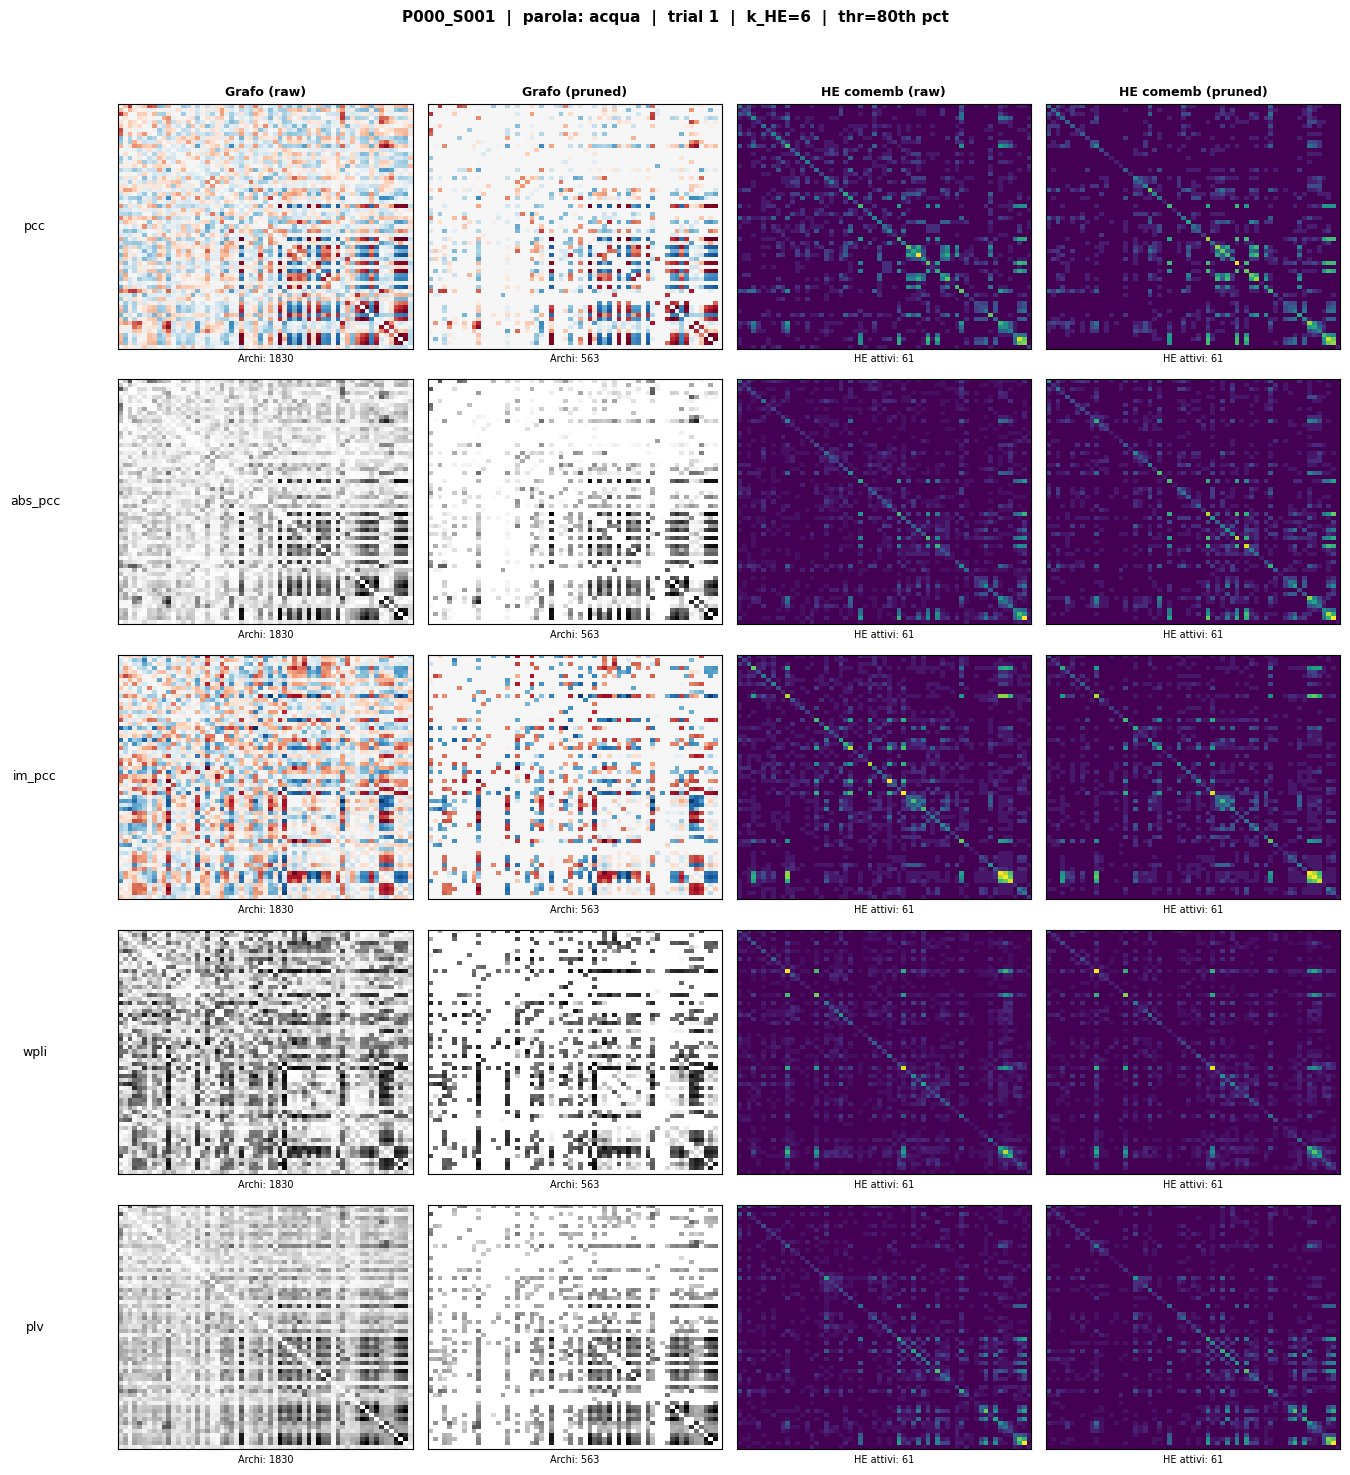

In [12]:
# ============================================================
# VISUALIZZAZIONE — grafi e ipergrafi (pruned / raw) per trial
# Modifica solo i 3 parametri qui sotto, poi esegui la cella.
# Richiede che il main loop (cella 8) sia già stato eseguito.
# ============================================================

import matplotlib.pyplot as plt

VIZ_SUBJ_ID = 0           # es. 0 → P000
VIZ_SESS_ID = 1           # es. 1 → S001
VIZ_WORD    = "acqua" # parola senza _img.csv

# ---- risolvi trial_idx dalla posizione nel glob ----
_sess_dir  = CSV_ROOT / f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}"
_csv_files = sorted(_sess_dir.glob("*_img.csv"))
_trial_idx = next(
    (i for i, p in enumerate(_csv_files) if p.stem == f"{VIZ_WORD}_img"),
    None,
)
if _trial_idx is None:
    raise FileNotFoundError(f"'{VIZ_WORD}' non trovata in {_sess_dir}")
print(f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}  |  {VIZ_WORD}  |  trial_idx={_trial_idx}")

# ---- carica tutti i .pt per questo trial ----
_KINDS   = ["graphs", "graphs_pruned", "hypergraphs", "hypergraphs_pruned"]
_loaded  = {}
for _metric in METRICS:
    for _kind in _KINDS:
        _pt = _out_path(DATA_OUT, _metric, "pruned" in _kind,
                        VIZ_SUBJ_ID, VIZ_SESS_ID, _trial_idx) \
              if "hypergraph" not in _kind else \
              _out_path_hg(DATA_OUT, _metric, "pruned" in _kind,
                           VIZ_SUBJ_ID, VIZ_SESS_ID, _trial_idx)
        _loaded[(_kind, _metric)] = (
            torch.load(_pt, weights_only=False) if _pt.exists() else None
        )

# ---- figura: righe=metriche, colonne=4 varianti ----
_COL_LABELS = ["Grafo (raw)", "Grafo (pruned)", "HE comemb (raw)", "HE comemb (pruned)"]
_SIGNED     = {"pcc", "im_pcc"}   # metriche con valori negativi → RdBu_r

n_r, n_c = len(METRICS), 4
fig, axes = plt.subplots(n_r, n_c, figsize=(n_c * 3.4, n_r * 3.0))
if n_r == 1:
    axes = axes[np.newaxis, :]

for ri, metric in enumerate(METRICS):
    axes[ri, 0].set_ylabel(metric, fontsize=9, rotation=0,
                            labelpad=60, va="center")

    for ci, kind in enumerate(_KINDS):
        ax   = axes[ri, ci]
        data = _loaded.get((kind, metric))

        if data is None:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="gray")
            ax.set_xticks([]); ax.set_yticks([])
            continue

        if "hypergraph" in kind:
            # co-membership: H @ H.T  →  quante HE condividono i e j
            H_np = data["H"].numpy()            # (N, N_he)
            mat  = H_np @ H_np.T                # (N, N)
            vmax = mat.max() if mat.max() > 0 else 1.0
            ax.imshow(mat, cmap="viridis", vmin=0, vmax=vmax,
                      aspect="auto", interpolation="nearest")
            n_he = int((H_np.sum(axis=0) > 0).sum())
            ax.set_xlabel(f"HE attivi: {n_he}", fontsize=7)
        else:
            adj_np = data["adj"].numpy()        # (N, N)
            vmax   = np.abs(adj_np).max() or 1.0
            if metric in _SIGNED:
                ax.imshow(adj_np, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                          aspect="auto", interpolation="nearest")
            else:
                ax.imshow(adj_np, cmap="Greys", vmin=0, vmax=vmax,
                          aspect="auto", interpolation="nearest")
            n_edges = int(data["edge_index"].shape[1] // 2)
            ax.set_xlabel(f"Archi: {n_edges}", fontsize=7)

        ax.set_xticks([]); ax.set_yticks([])

for ci, lbl in enumerate(_COL_LABELS):
    axes[0, ci].set_title(lbl, fontsize=9, fontweight="bold")

fig.suptitle(
    f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}  |  parola: {VIZ_WORD}"
    f"  |  trial {_trial_idx}  |  k_HE={K_HYPEREDGE}  |  thr={EDGE_THRESHOLD_PCT}th pct",
    fontsize=11, fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.96])

_out_viz = project_root / "figures" / (
    f"eeg07f_viz_P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}_{VIZ_WORD}.png"
)
fig.savefig(_out_viz, dpi=150, bbox_inches="tight")
print(f"Salvato: {_out_viz}")
plt.show()


In [13]:
def _node_scalar(data_obj) -> np.ndarray:
    if data_obj is None:
        return np.zeros(N_CH)

    d = data_obj if isinstance(data_obj, dict) else data_obj.__dict__

    if "H" in d:
        # ipergrafo: H shape (N, N_he) → quante HE include ogni nodo
        H_np = d["H"].numpy() if isinstance(d["H"], torch.Tensor) else np.array(d["H"])
        v = H_np.sum(axis=1)
    elif "adj" in d:
        # grafo: grado pesato
        adj = d["adj"]
        adj_np = adj.numpy() if isinstance(adj, torch.Tensor) else np.array(adj)
        v = np.abs(adj_np).sum(axis=1)
    elif "edge_index" in d:
        idx = d["edge_index"][0]
        idx_np = idx.cpu().numpy() if isinstance(idx, torch.Tensor) else np.array(idx)
        v = np.bincount(idx_np, minlength=N_CH).astype(float)[:N_CH]
    else:
        return np.zeros(N_CH)

    v = np.asarray(v, dtype=float)
    mx = v.max()
    return v / (mx + 1e-8) if mx > 0 else v


# debug corretto: per HE mostra hyperedge attivi, non "connessioni"
for metric in METRICS:
    for kind in _KINDS:
        data = _loaded.get((kind, metric))
        if data is None: continue
        d = data if isinstance(data, dict) else data.__dict__
        if "H" in d:
            n_e = int((d["H"].sum(axis=0) > 0).sum())
            print(f"DEBUG: {metric} {kind} → {n_e} HE attivi")
        else:
            ei = d.get("edge_index", torch.zeros(2, 0))
            print(f"DEBUG: {metric} {kind} → {ei.shape[-1]} archi")

DEBUG: pcc graphs → 3660 archi
DEBUG: pcc graphs_pruned → 1126 archi
DEBUG: pcc hypergraphs → 61 HE attivi
DEBUG: pcc hypergraphs_pruned → 61 HE attivi
DEBUG: abs_pcc graphs → 3660 archi
DEBUG: abs_pcc graphs_pruned → 1126 archi
DEBUG: abs_pcc hypergraphs → 61 HE attivi
DEBUG: abs_pcc hypergraphs_pruned → 61 HE attivi
DEBUG: im_pcc graphs → 3660 archi
DEBUG: im_pcc graphs_pruned → 1126 archi
DEBUG: im_pcc hypergraphs → 61 HE attivi
DEBUG: im_pcc hypergraphs_pruned → 61 HE attivi
DEBUG: wpli graphs → 3660 archi
DEBUG: wpli graphs_pruned → 1126 archi
DEBUG: wpli hypergraphs → 61 HE attivi
DEBUG: wpli hypergraphs_pruned → 61 HE attivi
DEBUG: plv graphs → 3660 archi
DEBUG: plv graphs_pruned → 1126 archi
DEBUG: plv hypergraphs → 61 HE attivi
DEBUG: plv hypergraphs_pruned → 61 HE attivi


Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/topomap_P000_acqua.png


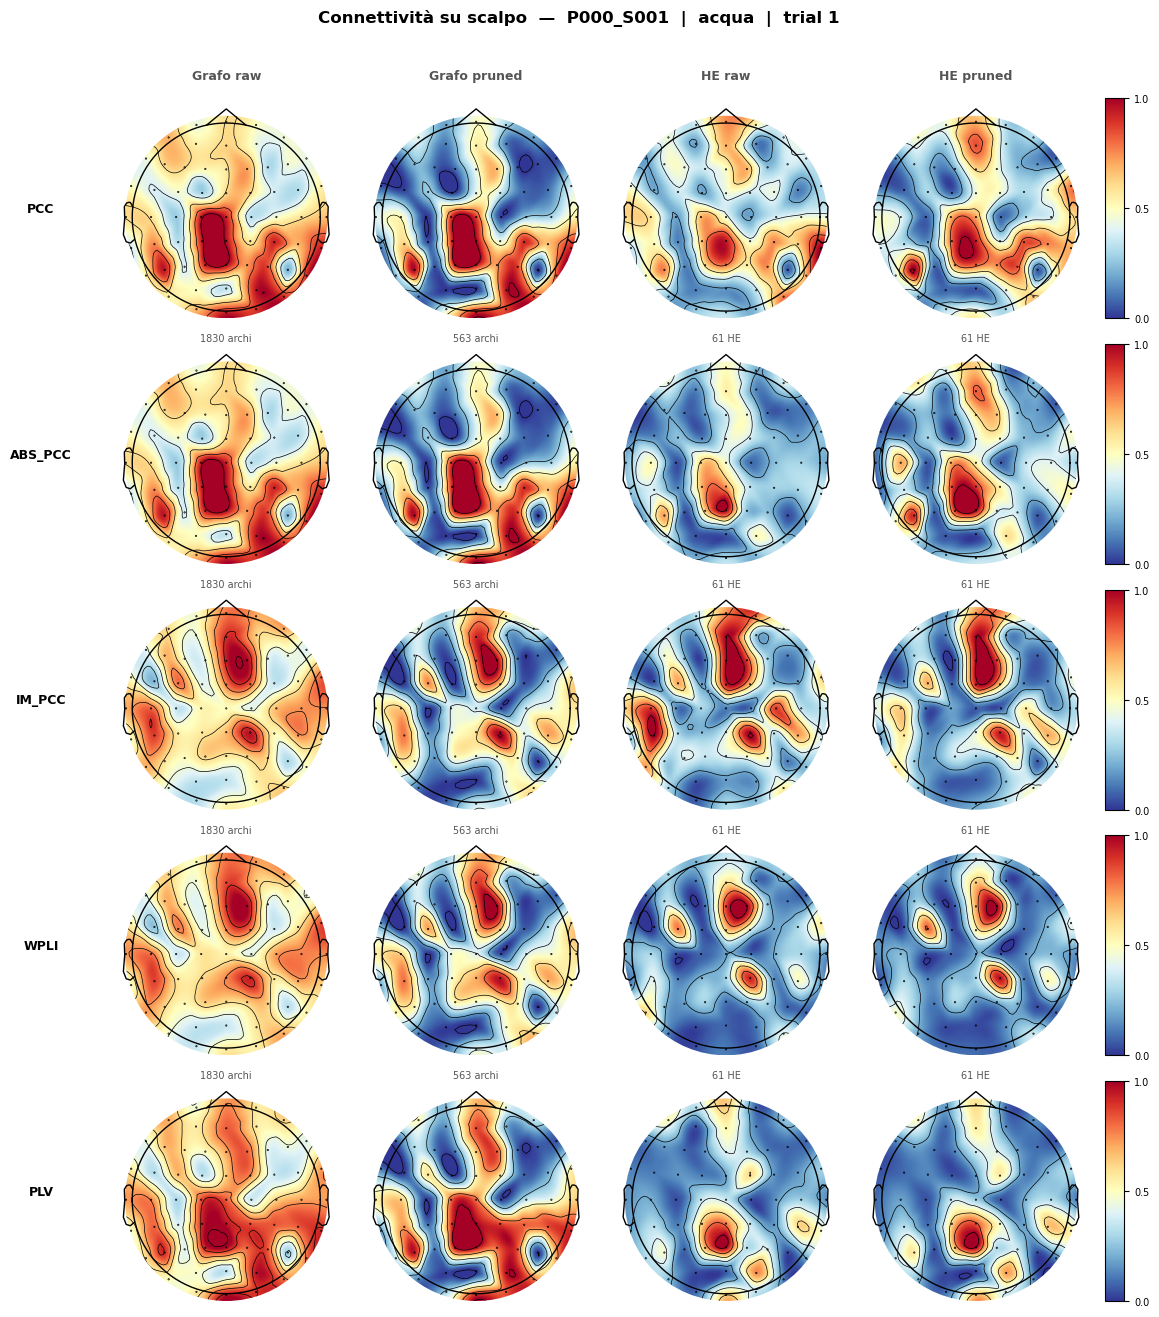

In [14]:
# ============================================================
# TOPOMAP CONNETTIVITÀ SU SCALPO
# ============================================================
import mne, torch, numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from pathlib import Path

VIZ_SUBJ_ID = 0
VIZ_SESS_ID = 1
VIZ_WORD    = "acqua"
N_CH        = 61

# ---- montage ----
_RENAME = {"T3": "T7", "T4": "T8", "T5": "P7", "T6": "P8"}
_BAD    = {"A1", "A2"}
ELOC_FILE = project_root / "src" / "io" / "ebneuro.locs"

_raw_montage = mne.channels.read_custom_montage(str(ELOC_FILE), coord_frame="head")
_ch_pos  = {_RENAME.get(ch, ch): pos
            for ch, pos in _raw_montage.get_positions()["ch_pos"].items()
            if ch not in _BAD}
_montage = mne.channels.make_dig_montage(ch_pos=_ch_pos, coord_frame="head")
ch_names = [_RENAME.get(ch, ch) for ch in _raw_montage.ch_names if ch not in _BAD][:N_CH]

info = mne.create_info(ch_names=ch_names, sfreq=256, ch_types="eeg")
info.set_montage(_montage, on_missing="warn")

# ---- scalare per nodo ----
def _node_scalar(data: dict) -> np.ndarray:
    """
    Grafo     → grado pesato: sum(|adj|, axis=1)
    Ipergrafo → membership:   sum(H,     axis=1)
    """
    if "H" in data:
        v = data["H"].numpy().sum(axis=1)           # (N,)
    elif "adj" in data:
        v = np.abs(data["adj"].numpy()).sum(axis=1)  # (N,)
    else:
        return np.zeros(N_CH)
    mx = v.max()
    return (v / (mx + 1e-8)) if mx > 0 else v

# ---- risolvi trial_idx ----
_sess_dir  = CSV_ROOT / f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}"
_trial_idx = next(
    (i for i, p in enumerate(sorted(_sess_dir.glob("*_img.csv")))
     if p.stem == f"{VIZ_WORD}_img"), None
)
if _trial_idx is None:
    raise FileNotFoundError(f"'{VIZ_WORD}' non trovata in {_sess_dir}")

# ---- carica .pt ----
_KINDS = ["graphs", "graphs_pruned", "hypergraphs", "hypergraphs_pruned"]
_loaded = {}
for m in METRICS:
    for k in _KINDS:
        pt = (DATA_OUT / f"{k}_{m}"
              / f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}"
              / f"trial_{_trial_idx:03d}.pt")
        _loaded[(k, m)] = torch.load(pt, weights_only=False) if pt.exists() else None

# ---- figura ----
_COL_TITLES = ["Grafo raw", "Grafo pruned", "HE raw", "HE pruned"]
_CMAP       = "RdYlBu_r"
n_r, n_c    = len(METRICS), len(_KINDS)

fig, axes = plt.subplots(
    n_r, n_c + 1,                          # +1 colonna destra per colorbar
    figsize=(n_c * 2.8 + 0.5, n_r * 2.6),
    gridspec_kw={"width_ratios": [1] * n_c + [0.08]},
)

norm = Normalize(vmin=0, vmax=1)
sm   = ScalarMappable(cmap=_CMAP, norm=norm)
sm.set_array([])

for ri, metric in enumerate(METRICS):
    axes[ri, 0].set_ylabel(
        metric.upper(), fontsize=9, fontweight="bold",
        rotation=0, labelpad=52, va="center",
    )
    for ci, kind in enumerate(_KINDS):
        ax   = axes[ri, ci]
        data = _loaded.get((kind, metric))

        if data is None:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="#aaa")
            ax.axis("off")
            continue

        vals = _node_scalar(data)
        mne.viz.plot_topomap(
            vals, info, axes=ax,
            cmap=_CMAP, vlim=(0, 1),
            contours=5, show=False,
            extrapolate="head",
        )

        # annotazione n. archi / HE attivi
        if "H" in data:
            tag = f"{int((data['H'].sum(axis=0) > 0).sum())} HE"
        else:
            tag = f"{int(data['edge_index'].shape[1] // 2)} archi"
        ax.set_title(tag, fontsize=7, color="#555", pad=2)

    # colorbar per riga (nell'ultima colonna)
    plt.colorbar(sm, cax=axes[ri, -1]).set_ticks([0, 0.5, 1])
    axes[ri, -1].tick_params(labelsize=7)

# intestazioni colonne
for ci, lbl in enumerate(_COL_TITLES):
    axes[0, ci].set_title(lbl, fontsize=9, fontweight="bold", pad=14)

fig.suptitle(
    f"Connettività su scalpo  —  "
    f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}  |  {VIZ_WORD}  |  trial {_trial_idx}",
    fontsize=12, fontweight="bold", y=1.01,
)
fig.tight_layout()

_out = project_root / "figures" / f"topomap_P{VIZ_SUBJ_ID:03d}_{VIZ_WORD}.png"
fig.savefig(_out, dpi=160, bbox_inches="tight")
print(f"Salvato: {_out}")
plt.show()

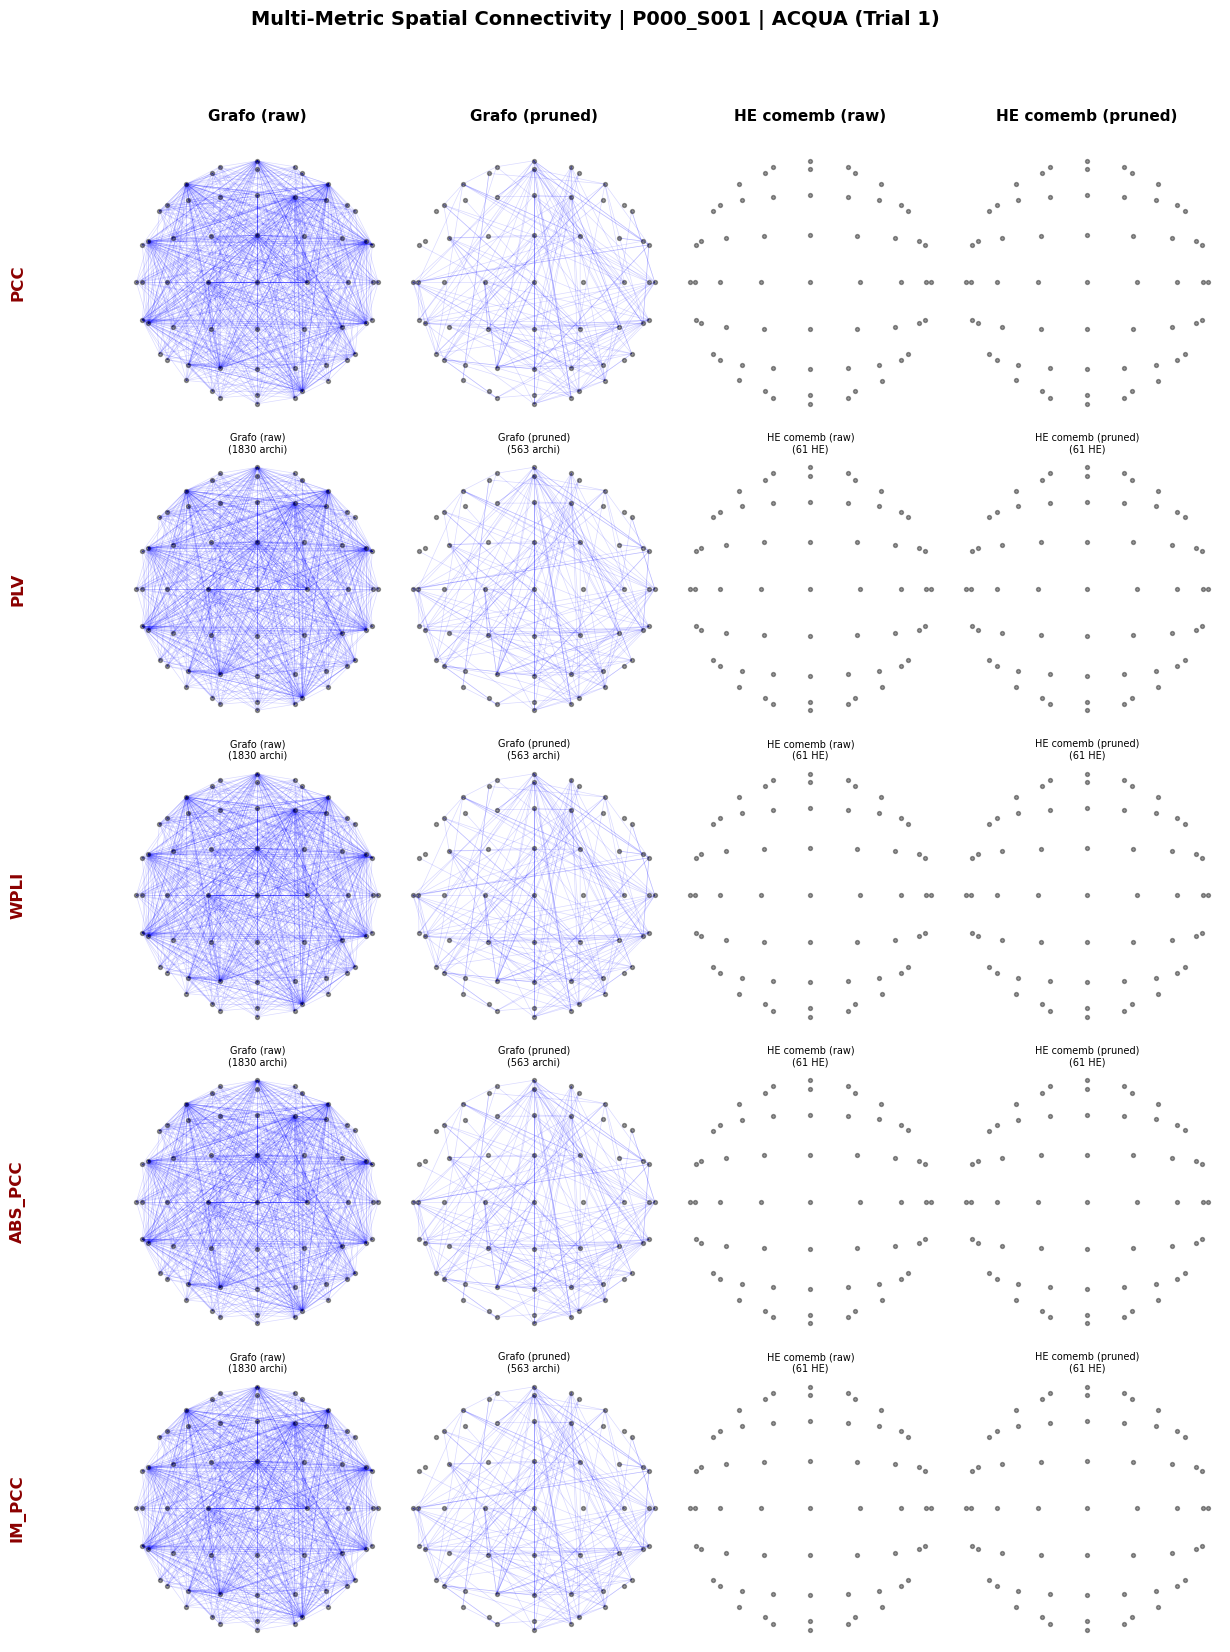

In [15]:
# [ignoring loop detection]
# MEGA-GRID SPAZIALE: Tutte le 5 metriche incluse
# ============================================================

# ---- Parametri di Visualizzazione Aggiornati ----
VIZ_SUBJ_ID = 0
VIZ_SESS_ID = 1
VIZ_WORD    = "acqua"
# Includiamo tutte le metriche presenti nel dataset
METRICS_MAP = ["pcc", "plv", "wpli", "abs_pcc", "im_pcc"] 

def plot_spatial_connectivity(data, info, ax, kind="graph", title=""):
    pos = {i: info['chs'][i]['loc'][:2] for i in range(len(info['chs']))}
    x_coords, y_coords = [p[0] for p in pos.values()], [p[1] for p in pos.values()]
    ax.scatter(x_coords, y_coords, c='black', s=8, zorder=5, alpha=0.4)
    
    if data is None:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes, color="gray")
        ax.axis("off"); return

    if "hyper" in kind:
        he_idx = data.get('hyperedge_index', data.get('H'))
        if he_idx is not None:
            if he_idx.shape[0] == N_CH and he_idx.shape[1] != 2:
                ii, jj = torch.where(he_idx > 0); he_idx = torch.stack([ii, jj])
            n_he = int(he_idx[1].max() + 1)
            for e_id in range(0, n_he, 6):
                nodes = he_idx[0][he_idx[1] == e_id].cpu().numpy()
                if len(nodes) >= 3:
                    pts = np.array([pos[n] for n in nodes])
                    try:
                        hull = ConvexHull(pts)
                        ax.add_patch(patches.Polygon(pts[hull.vertices], alpha=0.12, 
                                                     facecolor=plt.cm.tab10(e_id%10), edgecolor='black', lw=0.4))
                    except: pass
            tag = f"{n_he} HE"
    else:
        ei = data.get('edge_index', data.get('adj'))
        if ei is not None:
            if ei.shape[0] == N_CH and ei.shape[1] == N_CH:
                ii, jj = torch.where(ei > 0); ei = torch.stack([ii, jj])
            edge_subset = ei[:, ::5]
            for s, t in edge_subset.t().cpu().numpy():
                if s < len(pos) and t < len(pos):
                    p1, p2 = pos[s], pos[t]
                    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='blue', alpha=0.15, lw=0.5)
            tag = f"{ei.shape[1]//2} archi"

    ax.set_title(f"{title}\n({tag})", fontsize=7, pad=2)
    ax.set_aspect('equal')
    ax.axis('off')

# ---- Generazione Figura ----
n_r, n_c = len(METRICS_MAP), len(_KINDS)
fig, axes = plt.subplots(n_r, n_c, figsize=(n_c * 3.2, n_r * 3.2), squeeze=False)
for ri, m in enumerate(METRICS_MAP):
    # Usiamo annotate invece di ylabel per bypassare ax.axis('off')
    axes[ri, 0].annotate(m.upper(), xy=(-0.4, 0.5), xycoords='axes fraction',
                         fontsize=12, fontweight="bold", ha='center', va='center',
                         rotation=90, color="darkred")
    
    for ci, k in enumerate(_KINDS):
        ax = axes[ri, ci]
        data = _loaded.get((k, m)) 
        plot_spatial_connectivity(data, info, ax, kind=k, title=_COL_LABELS[ci])
# Titoli delle colonne
for ci, lbl in enumerate(_COL_LABELS):
    axes[0, ci].set_title(lbl, fontsize=11, fontweight="bold", pad=20)
fig.suptitle(f"Multi-Metric Spatial Connectivity | P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d} | {VIZ_WORD.upper()} (Trial {_trial_idx})", 
             fontsize=14, fontweight="bold", y=1.03)
# Aumentiamo il margine sinistro per far stare i nomi delle metriche
plt.tight_layout(rect=[0.05, 0, 1, 1]) 
plt.show()


In [16]:
# ============================================================
# DIPENDENZE ANALISI — installa se assenti
# ============================================================
import subprocess, sys

_PKGS = [
    ("community",       "python-louvain"),
    ("statannotations", "statannotations"),
]
for _imp, _pkg in _PKGS:
    try:
        __import__(_imp)
        print(f"  ✓ {_pkg}")
    except ImportError:
        print(f"  Installing {_pkg} …")
        subprocess.check_call([sys.executable, "-m", "pip", "install", _pkg, "-q"])
        print(f"  ✓ {_pkg} (installed)")
print("Dependencies OK.")

  ✓ python-louvain
  ✓ statannotations
Dependencies OK.


Topological metrics:   0%|          | 0/110 [00:00<?, ?it/s]

/tmp/ipykernel_1510631/2606631440.py:112: UserWarning: Grafo disconnesso (5 comp.) — uso LCC per avg_path
  for _mn, _mv in _topo_metrics(_A).items():
/tmp/ipykernel_1510631/2606631440.py:112: UserWarning: Grafo disconnesso (2 comp.) — uso LCC per avg_path
  for _mn, _mv in _topo_metrics(_A).items():
/tmp/ipykernel_1510631/2606631440.py:112: UserWarning: Grafo disconnesso (6 comp.) — uso LCC per avg_path
  for _mn, _mv in _topo_metrics(_A).items():
/tmp/ipykernel_1510631/2606631440.py:112: UserWarning: Grafo disconnesso (3 comp.) — uso LCC per avg_path
  for _mn, _mv in _topo_metrics(_A).items():
/tmp/ipykernel_1510631/2606631440.py:112: UserWarning: Grafo disconnesso (4 comp.) — uso LCC per avg_path
  for _mn, _mv in _topo_metrics(_A).items():
/tmp/ipykernel_1510631/2606631440.py:112: UserWarning: Grafo disconnesso (12 comp.) — uso LCC per avg_path
  for _mn, _mv in _topo_metrics(_A).items():


Trials: 110  |  cluster dist: {0: 18, 1: 27, 2: 21, 3: 44}


/tmp/ipykernel_1510631/2606631440.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1510631/2606631440.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1510631/2606631440.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1510631/2606631440.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1510631/26066

Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg07f_topo_metrics_P000_S001.png


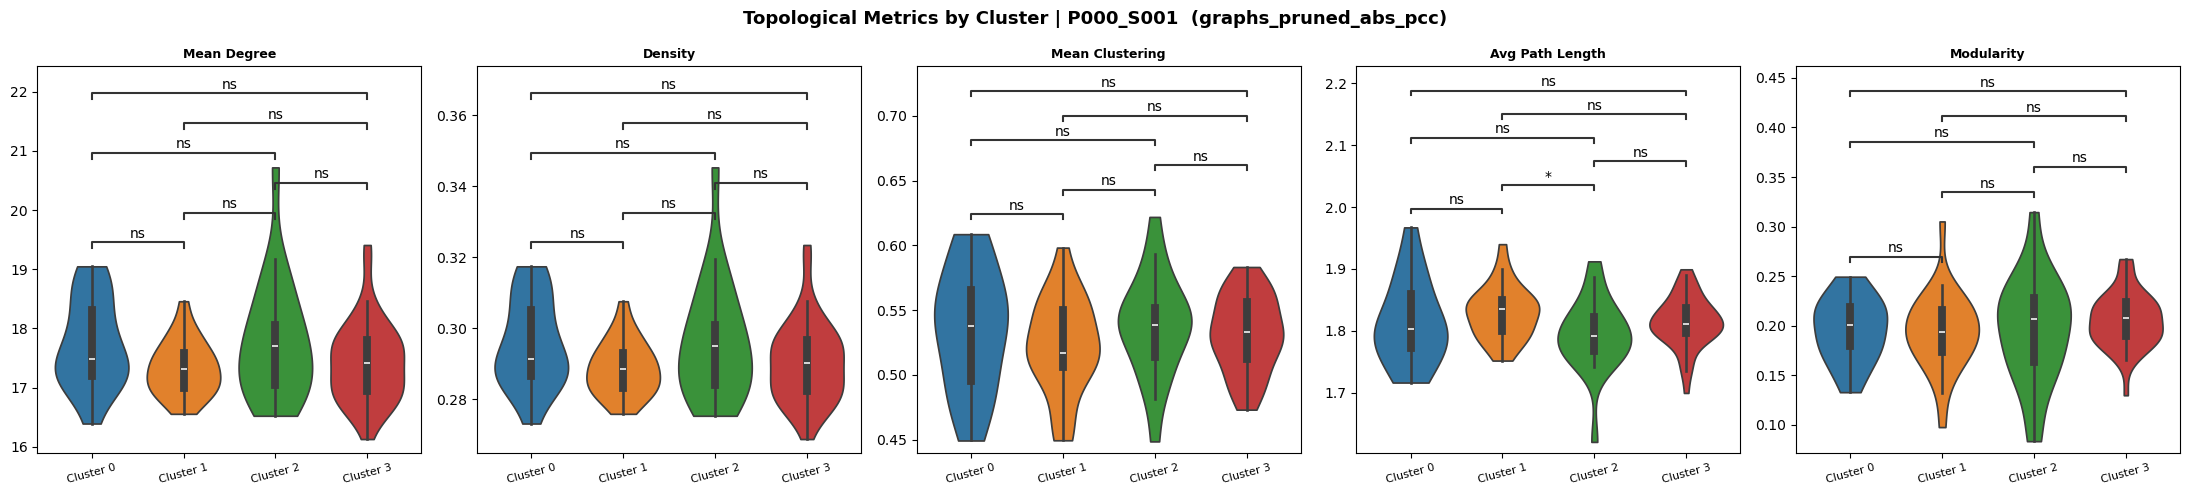

In [17]:
# ============================================================
# CELL 1 — Metriche topologiche per cluster (violin + Mann-Whitney)
# Dipende da: VIZ_SUBJ_ID, VIZ_SESS_ID, N_CH, DATA_OUT, CSV_ROOT,
#             project_root, word2label (tutti in scope da celle precedenti)
# ============================================================
import json
import warnings
from itertools import combinations

import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from tqdm.auto import tqdm

try:
    import community as community_louvain
    _HAS_LOUVAIN = True
except ImportError:
    _HAS_LOUVAIN = False
    warnings.warn("python-louvain non installato — colonna 'modularity' sarà NaN")

try:
    from statannotations.Annotator import Annotator as _StatAnnotator
    _HAS_STATANN = True
except ImportError:
    _HAS_STATANN = False

# ── Config ─────────────────────────────────────────────────────────────────────
_TOPO_KIND  = "graphs_pruned_abs_pcc"   # directory .pt da usare

# Nomi cluster (usa CLUSTER_NAMES se definito in scope)
try:
    _CN1 = {i: CLUSTER_NAMES[i] for i in range(4)}
except (NameError, KeyError):
    _CN1 = {i: f"Cluster {i}" for i in range(4)}

# y nel .pt è word_label (0-109) — mappiamo a cluster (0-3)
_lmap1_path = project_root / "configs" / "label_schemes" / "labelid2cluster_concr4.json"
if _lmap1_path.exists():
    _lmap1 = {int(k): int(v) for k, v in json.loads(_lmap1_path.read_text()).items()}
    _y1c   = lambda y: _lmap1.get(int(y), int(y)) if int(y) > 3 else int(y)
else:
    _y1c = lambda y: int(y)

(project_root / "figures").mkdir(exist_ok=True)

# ── Calcolo metriche topologiche ───────────────────────────────────────────────
def _topo_metrics(adj_np: np.ndarray) -> dict:
    """
    Riceve matrice adj [N×N] float, restituisce dict metriche scalari.
    avg_path_length: calcolato sulla LCC se il grafo è disconnesso.
    """
    A = (np.abs(adj_np) > 0).astype(float)
    np.fill_diagonal(A, 0.0)
    G = nx.from_numpy_array(A)

    degs        = np.array([d for _, d in G.degree()], dtype=float)
    mean_degree = float(degs.mean())

    N         = A.shape[0]
    n_edges   = int(A.sum()) // 2
    max_edges = N * (N - 1) / 2
    density   = n_edges / max_edges if max_edges > 0 else 0.0

    mean_clust = nx.average_clustering(G)

    if nx.is_connected(G):
        avg_path = nx.average_shortest_path_length(G)
    else:
        _comps = list(nx.connected_components(G))
        if len(_comps) > 1:
            warnings.warn(
                f"Grafo disconnesso ({len(_comps)} comp.) — uso LCC per avg_path",
                stacklevel=2,
            )
        _lcc = G.subgraph(max(_comps, key=len)).copy()
        avg_path = nx.average_shortest_path_length(_lcc) if len(_lcc) > 1 else float("nan")

    if _HAS_LOUVAIN:
        _part = community_louvain.best_partition(G, random_state=42)
        mod   = community_louvain.modularity(_part, G)
    else:
        mod = float("nan")

    return {
        "mean_degree":     mean_degree,
        "density":         density,
        "mean_clustering": mean_clust,
        "avg_path_length": avg_path,
        "modularity":      mod,
    }


# ── Stream trial-by-trial ──────────────────────────────────────────────────────
_sess1     = f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}"
_gdir1     = DATA_OUT / _TOPO_KIND / _sess1
_ptfiles1  = sorted(_gdir1.glob("trial_*.pt"))

if not _ptfiles1:
    raise FileNotFoundError(f"Nessun .pt in {_gdir1}")

_rows1 = []
for _pt in tqdm(_ptfiles1, desc="Topological metrics", leave=True):
    _d = torch.load(_pt, weights_only=False, map_location="cpu")
    _c = _y1c(_d["y"])
    _A = _d["adj"].numpy() if isinstance(_d["adj"], torch.Tensor) else np.asarray(_d["adj"])
    _ti = int(_d["meta"]["trial_idx"])
    try:
        for _mn, _mv in _topo_metrics(_A).items():
            _rows1.append({"trial_idx": _ti, "cluster": _c,
                           "metric": _mn, "value": _mv})
    except Exception as _exc:
        warnings.warn(f"{_pt.name}: {_exc}")

topo_df = pd.DataFrame(_rows1)
print(f"Trials: {topo_df['trial_idx'].nunique()}  |  "
      f"cluster dist: {topo_df.drop_duplicates('trial_idx')['cluster'].value_counts().sort_index().to_dict()}")

# ── Figura: 5 violin ───────────────────────────────────────────────────────────
_MNAMES1 = ["mean_degree", "density", "mean_clustering", "avg_path_length", "modularity"]
fig1, axes1 = plt.subplots(1, 5, figsize=(22, 5))

for ax, mname in zip(axes1, _MNAMES1):
    _sub = topo_df[topo_df["metric"] == mname].dropna(subset=["value"]).copy()
    _sub["cname"] = _sub["cluster"].map(_CN1)

    _present = sorted(_sub["cluster"].unique())
    _order   = [_CN1[c] for c in _present]

    sns.violinplot(
        data=_sub, x="cname", y="value",
        order=_order, palette="tab10",
        inner="box", cut=0, ax=ax,
    )
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_title(mname.replace("_", " ").title(), fontsize=9, fontweight="bold")
    ax.tick_params(axis="x", labelsize=8, rotation=15)

    # Coppie per annotazione statistica
    _pairs_names = [(_CN1[c1], _CN1[c2])
                    for c1, c2 in combinations(_present, 2)]

    if _HAS_STATANN and _pairs_names:
        try:
            _ann = _StatAnnotator(ax, _pairs_names, data=_sub,
                                  x="cname", y="value", order=_order)
            _ann.configure(test="Mann-Whitney", text_format="star",
                           loc="inside", verbose=False)
            _ann.apply_and_annotate()
        except Exception as _ae:
            warnings.warn(f"statannotations [{mname}]: {_ae}")
    else:
        # Fallback: stelle nel titolo
        _sig = []
        for c1, c2 in combinations(_present, 2):
            g1 = _sub[_sub["cluster"] == c1]["value"].dropna()
            g2 = _sub[_sub["cluster"] == c2]["value"].dropna()
            if len(g1) > 1 and len(g2) > 1:
                _, _p = mannwhitneyu(g1, g2, alternative="two-sided")
                _s = ("***" if _p < 0.001 else "**" if _p < 0.01
                      else "*" if _p < 0.05 else None)
                if _s:
                    _sig.append(f"{_CN1[c1][:4]}v{_CN1[c2][:4]}:{_s}")
        if _sig:
            ax.set_title(
                f"{mname.replace('_',' ').title()}\n{', '.join(_sig)}",
                fontsize=7, fontweight="bold",
            )

fig1.suptitle(
    f"Topological Metrics by Cluster | {_sess1}  ({_TOPO_KIND})",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
_fig1_out = project_root / "figures" / f"eeg07f_topo_metrics_{_sess1}.png"
fig1.savefig(_fig1_out, dpi=150, bbox_inches="tight")
print(f"Salvato: {_fig1_out}")
plt.show()

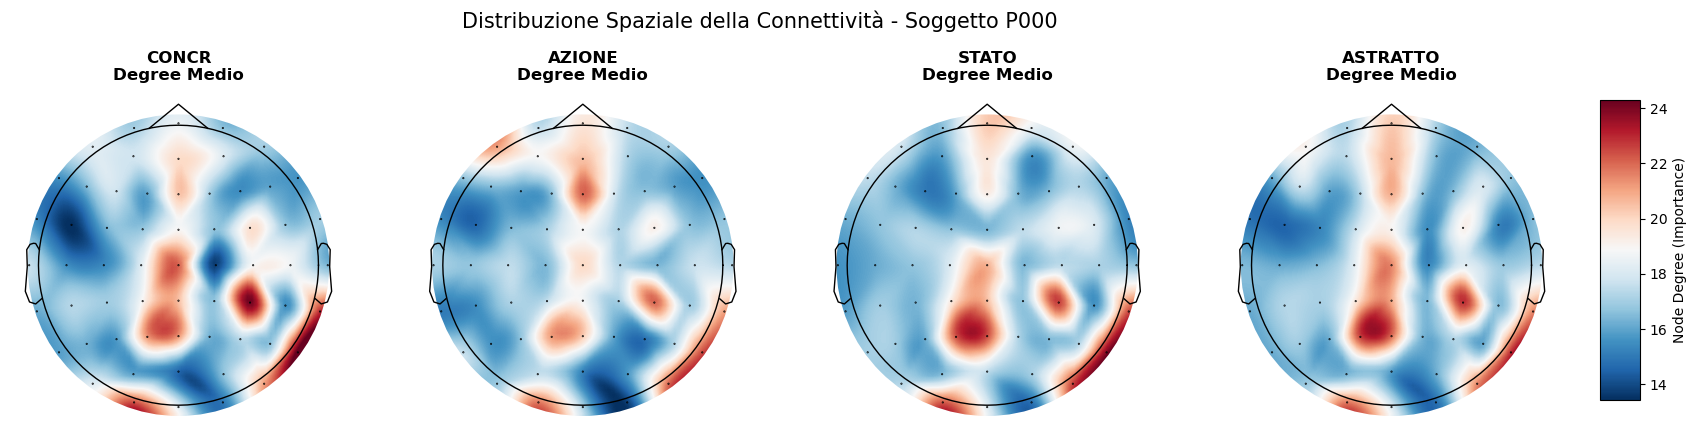

In [18]:
import torch
import numpy as np
import mne
import matplotlib.pyplot as plt
from pathlib import Path
import json

# --- CONFIGURAZIONE ---
subject_id = "P000"
metric = "abs_pcc"
base_path = project_root / "data" / f"graphs_pruned_{metric}"

ELOC_FILE = project_root / "src" / "io" / "ebneuro.locs"

_raw_montage = mne.channels.read_custom_montage(str(ELOC_FILE), coord_frame="head")
_ch_pos  = {_RENAME.get(ch, ch): pos
            for ch, pos in _raw_montage.get_positions()["ch_pos"].items()
            if ch not in _BAD}
_montage = mne.channels.make_dig_montage(ch_pos=_ch_pos, coord_frame="head")
ch_names = [_RENAME.get(ch, ch) for ch in _raw_montage.ch_names if ch not in _BAD][:N_CH]

info = mne.create_info(ch_names=ch_names, sfreq=256, ch_types="eeg")
info.set_montage(_montage, on_missing="warn")

# 1. Caricamento Mapping
with open(project_root / "configs" / "label_schemes" / "labelid2cluster_concr4.json", "r") as f:
    word2cluster = json.load(f)
with open(project_root / "configs" / "label_schemes" / "cluster_names_concr4.json", "r") as f:
    cluster_names = json.load(f)

# 3. Raccolta Degree per Classe
cluster_degrees = {int(k): [] for k in cluster_names.keys()}
pt_files = list(base_path.glob(f"{subject_id}_S*/*.pt"))

for f in pt_files:
    d = torch.load(f, weights_only=False)
    c_idx = int(word2cluster[str(int(d['y']))])
    # Calcoliamo il degree di ogni nodo (somma delle connessioni incidenti)
    adj = d['adj'].numpy() > 0
    degree = np.sum(adj, axis=1)
    cluster_degrees[c_idx].append(degree)

# 4. Plot delle Topomaps
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Cerchiamo il valore massimo per avere la stessa scala di colori (vmax)
all_means = [np.mean(cluster_degrees[c], axis=0) for c in cluster_degrees if cluster_degrees[c]]
global_vmax = np.max(all_means) if all_means else 1
global_vmin = np.min(all_means) if all_means else 0

for i, c_idx in enumerate(sorted(cluster_degrees.keys())):
    if not cluster_degrees[c_idx]: continue
    
    mean_degree = np.mean(cluster_degrees[c_idx], axis=0)
    
    im, _ = mne.viz.plot_topomap(mean_degree, info, axes=axes[i], show=False, 
                                 cmap='RdBu_r', contours=0, sensors=True,
                                 vlim=(global_vmin, global_vmax))
    
    axes[i].set_title(f"{cluster_names[str(c_idx)]}\nDegree Medio", fontweight='bold')

# Aggiungiamo una colorbar comune
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
clb = fig.colorbar(im, cax=cbar_ax)
clb.set_label('Node Degree (Importance)')

plt.suptitle(f"Distribuzione Spaziale della Connettività - Soggetto {subject_id}", fontsize=15)
plt.show()


In [ ]:
# ============================================================
# PLOTLY V3 — vista dall'alto fissa + loop soggetti × metriche
# Salva PNG in data/processed/graph_comparison/P{xxx}/{graph_type}.png
# Richiede: pip install kaleido  (per fig.write_image)
# ============================================================
import subprocess, sys
try:
    import kaleido
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kaleido", "-q"])

from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np
import mne
import torch
import os
from pathlib import Path

try:
    _CLABELS = _CN1
except NameError:
    _CLABELS = {0: "Cluster 0", 1: "Cluster 1", 2: "Cluster 2", 3: "Cluster 3"}


# ── Funzioni invariate ────────────────────────────────────────────────────────
def _load_degrees(subject_id: str, metric: str) -> dict:
    out = {c: [] for c in range(4)}
    pts = list(
        (project_root / "data" / f"graphs_pruned_{metric}")
        .glob(f"{subject_id}_S*/*.pt")
    )
    if not pts:
        raise FileNotFoundError(f"Nessun .pt per {subject_id} metrica={metric}")
    for f in pts:
        d = torch.load(f, weights_only=False, map_location="cpu")
        c = _lmap1.get(int(d["y"]), int(d["y"]))
        out[c].append(np.sum(d["adj"].numpy() > 0, axis=1).astype(float))
    return out


def _build_inverse(info):
    """Costruisce fwd+inv su fsaverage. Chiamare UNA VOLTA sola."""
    fs_dir       = mne.datasets.fetch_fsaverage(verbose=False)
    subjects_dir = str(Path(fs_dir).parent)
    src = mne.setup_source_space(
        "fsaverage", spacing="oct5",
        subjects_dir=subjects_dir, add_dist=False, verbose=False,
    )
    bem = mne.read_bem_solution(
        os.path.join(fs_dir, "bem", "fsaverage-5120-5120-5120-bem-sol.fif"),
        verbose=False,
    )
    fwd    = mne.make_forward_solution(info, trans="fsaverage", src=src, bem=bem, eeg=True, verbose=False)
    inv_op = mne.minimum_norm.make_inverse_operator(
        info, fwd, mne.make_ad_hoc_cov(info, verbose=False), verbose=False,
    )
    return inv_op


def _compute_stcs(cluster_degrees: dict, info, inv_op):
    stc_vals, trial_cnts, coords = {}, {}, None
    for c_id, deg_list in cluster_degrees.items():
        if not deg_list:
            continue
        ev = mne.EvokedArray(np.mean(deg_list, axis=0)[:, np.newaxis], info)
        ev.set_eeg_reference(projection=True).apply_proj()
        stc = mne.minimum_norm.apply_inverse(
            ev, inv_op, lambda2=1.0/9.0, method="sLORETA", verbose=False,
        )
        stc_vals[c_id]   = stc.data.mean(axis=1)
        trial_cnts[c_id] = len(deg_list)
        if coords is None:
            s = inv_op["src"]
            coords = np.vstack([
                s[0]["rr"][s[0]["vertno"]],
                s[1]["rr"][s[1]["vertno"]],
            ])
    return stc_vals, trial_cnts, coords


# ── Visualizzazione — vista dall'alto fissa ────────────────────────────────────
import mne, os
from pathlib import Path

def plot_cluster_brain_dorsal(stcs: dict, subjects_dir: str,
                               out_path=None, colormap="hot"):
    """
    stcs: {cluster_id: mne.SourceEstimate}
    Render dorsal (top-down) con superficie corticale reale.
    """
    import tempfile, matplotlib.pyplot as plt, matplotlib.image as mpimg

    _cids  = sorted(stcs.keys())[:4]
    _vmin  = min(stcs[c].data.mean(axis=1).min() for c in _cids)
    _vmid  = min(stcs[c].data.mean(axis=1).mean() for c in _cids)
    _vmax  = max(stcs[c].data.mean(axis=1).max() for c in _cids)

    png_cache = {}
    with tempfile.TemporaryDirectory() as tmp:
        for c_id in _cids:
            brain = stcs[c_id].plot(
                subject      = "fsaverage",
                subjects_dir = subjects_dir,
                hemi         = "both",
                views        = "dorsal",   # ← vista dall'alto
                colormap     = colormap,
                clim         = dict(kind="value", lims=[_vmin, _vmid, _vmax]),
                background   = "white",
                foreground   = "black",
                colorbar     = False,
                time_viewer  = False,
                show_traces  = False,
                size         = (700, 550),
                verbose      = False,
            )
            _p = f"{tmp}/c{c_id}.png"
            brain.save_image(_p, mode="rgb")
            brain.close()
            png_cache[c_id] = mpimg.imread(_p).copy()

    # Composizione 2×2
    fig, axes = plt.subplots(2, 2, figsize=(13, 9),
                             gridspec_kw=dict(wspace=0.04, hspace=0.15))
    for i, c_id in enumerate(_cids):
        ax = axes[i // 2, i % 2]
        ax.imshow(png_cache[c_id])
        ax.axis("off")
        ax.set_title(
            f"{_CLABELS.get(c_id, f'C{c_id}')}   n={trial_cnts.get(c_id,'?')}",
            fontsize=13, fontweight="bold", pad=6,
        )

    # Colorbar condivisa
    import matplotlib.colors as _mc
    _sm = plt.cm.ScalarMappable(
        cmap=plt.get_cmap(colormap),
        norm=_mc.Normalize(vmin=_vmin, vmax=_vmax),
    )
    _sm.set_array([])
    fig.colorbar(_sm, ax=axes, label="sLORETA (a.u.)",
                 fraction=0.012, pad=0.02, shrink=0.7)

    fig.suptitle("Brain Signatures — dorsal view", fontsize=15, fontweight="bold")
    if out_path:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"Salvato: {out_path}")
    plt.show()
    return fig
    _cids      = sorted(stc_vals.keys())[:4]
    global_min = min(v.min() for v in stc_vals.values())
    global_max = max(v.max() for v in stc_vals.values()) or 1.0

    # ── Vista laterale sinistra — standard neuroimaging, no gap interemisferico ──
    # LH silhouette: x=L/R, y=P/A, z=I/S  →  eye da -x, up=z
    _camera = dict(
        eye    = dict(x=-2.4, y=0.1, z=0.3),
        up     = dict(x=0,    y=0,   z=1),
        center = dict(x=0,    y=0,   z=0),
    )
    _scene_cfg = dict(
        xaxis_visible=False,
        yaxis_visible=False,
        zaxis_visible=False,
        bgcolor="white",
        camera=_camera,
        aspectmode="data",   # non distorce, mantiene proporzioni reali
    )

    # subplot_titles gestisce placement automatico — niente overlap
    _titles = [
        f"{_CLABELS.get(c, f'C{c}')} · n={trial_cnts.get(c,'?')}"
        for c in _cids
    ]

    fig = make_subplots(
        rows=2, cols=2,
        specs=[[{"type": "scene"}] * 2] * 2,
        subplot_titles=_titles,
        horizontal_spacing=0.02,
        vertical_spacing=0.10,
    )

    _scenes = ["scene", "scene2", "scene3", "scene4"]

    for i, c_id in enumerate(_cids):
        r, c     = i // 2 + 1, i % 2 + 1
        is_last  = (i == len(_cids) - 1)

        fig.add_trace(
            go.Scatter3d(
                x=coords[:, 0],
                y=coords[:, 1],
                z=coords[:, 2],
                mode="markers",
                showlegend=False,
                marker=dict(
                    size=point_size,
                    color=stc_vals[c_id],
                    colorscale=colorscale,
                    cmin=global_min,
                    cmax=global_max,
                    opacity=0.90,
                    showscale=is_last,
                    colorbar=dict(
                        title=dict(text="sLORETA<br>(a.u.)", font=dict(size=11)),
                        thickness=14,
                        len=0.75,
                        x=1.02,
                        xanchor="left",
                        tickfont=dict(size=9),
                    ) if is_last else None,
                ),
            ),
            row=r, col=c,
        )
        fig.update_layout(**{_scenes[i]: _scene_cfg})

    # Titoli subplot: font più grande e bold
    for ann in fig.layout.annotations:
        ann.update(font=dict(size=14, color="black"), bgcolor="rgba(0,0,0,0)")

    fig.update_layout(
        title=dict(
            text=f"<b>{title}</b>",
            x=0.5, y=0.99,
            xanchor="center", yanchor="top",
            font=dict(size=16, color="#111"),
        ),
        paper_bgcolor="white",
        showlegend=False,          # rimuove "trace 0/1/2/3"
        height=900,
        width=1050,
        margin=dict(l=0, r=80, t=60, b=0),
        uirevision="fixed",
        font=dict(family="Arial, sans-serif", color="black"),
    )

    if out_path is not None:
        fig.write_image(str(out_path), width=2100, height=1800, scale=2)

    if show:
        fig.show()

    return fig
# ════════════════════════════════════════════════════════════
# LOOP — tutti i soggetti × tutte le metriche
# ════════════════════════════════════════════════════════════
base_export_dir = Path("/home/daniele_u/miralis-hypergraph-imagined-speech/data/processed/graph_comparison")
base_export_dir.mkdir(parents=True, exist_ok=True)

# Metriche disponibili (da directories graphs_pruned_*)
graph_types = sorted([
    d.name for d in (project_root / "data").glob("graphs_pruned_*")
    if d.is_dir()
])
print(f"Graph types ({len(graph_types)}): {graph_types}")

# Soggetti: union di tutti i P{xxx} presenti in almeno una directory
_all_subjects = sorted({
    pt.parent.name.split("_S")[0]       # "P000_S001" → "P000"
    for gt in graph_types
    for pt in (project_root / "data" / gt).glob("P*_S*/*.pt")
})
print(f"Soggetti trovati: {len(_all_subjects)}")

# ── Build inverse UNA VOLTA (fsaverage è uguale per tutti i soggetti) ─────────
print("Building inverse operator (solo una volta)…")
_inv_op_global = _build_inverse(info)
print("Inverse OK.")

# ── Loop principale ────────────────────────────────────────────────────────────
_errors = []

for g_kind in graph_types:
    metric = g_kind.replace("graphs_pruned_", "")
    print(f"\n{'='*55}")
    print(f"Metrica: {g_kind}")

    for subj_id in _all_subjects:
        out_dir  = base_export_dir / subj_id
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / f"{g_kind}.png"
        
        if out_path.exists():
            print(f"  SKIP  {subj_id} (già presente)")
            continue

        try:
            deg             = _load_degrees(subj_id, metric)
            sv, tc, co      = _compute_stcs(deg, info, _inv_op_global)

            if not sv:
                print(f"  WARN  {subj_id}: nessun cluster con dati — skip")
                continue

            _viz_plotly(
                sv, tc, co,
                title      = f"{subj_id} — {g_kind}",
                colorscale = "Plasma",
                out_path   = out_path,
                show       = False,   # non mostrare in loop
            )
            print(f"  OK    {subj_id}  →  {out_path.name}")

        except FileNotFoundError as e:
            print(f"  SKIP  {subj_id}: {e}")
        except Exception as e:
            print(f"  ERROR {subj_id}: {e}")
            _errors.append((subj_id, g_kind, str(e)))

print(f"\n{'='*55}")
print(f"Loop completo. Errori: {len(_errors)}")
for s, g, e in _errors:
    print(f"  {s} / {g}: {e}")

Graph types (5): ['graphs_pruned_abs_pcc', 'graphs_pruned_im_pcc', 'graphs_pruned_pcc', 'graphs_pruned_plv', 'graphs_pruned_wpli']
Soggetti trovati: 74
Building inverse operator (solo una volta)…


/tmp/ipykernel_1510631/2466743630.py:55: RuntimeWarning: No average EEG reference present in info["projs"], covariance may be adversely affected. Consider recomputing covariance using with an average eeg reference projector added.
  inv_op = mne.minimum_norm.make_inverse_operator(
/tmp/ipykernel_1510631/2466743630.py:55: RuntimeWarning: No average EEG reference present in info["projs"], covariance may be adversely affected. Consider recomputing covariance using with an average eeg reference projector added.
  inv_op = mne.minimum_norm.make_inverse_operator(


Inverse OK.

Metrica: graphs_pruned_abs_pcc
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items ac

/tmp/ipykernel_1510631/4155603061.py:181: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(str(out_path), width=2100, height=1800, scale=2)


  OK    P000  →  graphs_pruned_abs_pcc.png
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items act

KeyboardInterrupt: 

In [22]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import numpy as np
import torch
import mne
import json
import os.path as op
from mne.datasets import fetch_fsaverage
from pathlib import Path

# 1. SETUP AMBIENTE E MAPPING
fs_dir = fetch_fsaverage(verbose=False)
subjects_dir = op.dirname(fs_dir)
src_fs = op.join(fs_dir, 'bem', 'fsaverage-ico-5-src.fif')
bem_fs = op.join(fs_dir, 'bem', 'fsaverage-5120-5120-5120-bem-sol.fif')

# Caricamento Mapping Cluster
_map_path = project_root / "configs" / "label_schemes" / "labelid2cluster_concr4.json"
_name_path = project_root / "configs" / "label_schemes" / "cluster_names_concr4.json"

with open(_map_path, "r") as f:
    LID2C = json.load(f)
with open(_name_path, "r") as f:
    C_NAMES = json.load(f)

# Forza visualizzazione VS Code
pio.renderers.default = "notebook_connected"

def plot_cluster_averages_3d_plotly(subject_id, metric="abs_pcc"):
    # 1. Caricamento dati
    cluster_data_acc = {c: [] for c in range(4)}
    subj_files = list((project_root / "data" / f"graphs_pruned_{metric}").glob(f"{subject_id}_S*/*.pt"))
    
    if not subj_files:
        print(f"Nessun dato trovato per {subject_id}")
        return

    for f in subj_files:
        d = torch.load(f, weights_only=False)
        # Usiamo LID2C caricato sopra
        c_id = int(LID2C.get(str(int(d['y'])), d['y']))
        degree = np.sum(d['adj'].numpy() > 0, axis=1)
        if c_id < 4:
            cluster_data_acc[c_id].append(degree)

    # 2. Setup Forward/Inverse
    fwd = mne.make_forward_solution(info, trans='fsaverage', src=src_fs, bem=bem_fs, eeg=True, verbose=False)
    inv = mne.minimum_norm.make_inverse_operator(info, fwd, mne.make_ad_hoc_cov(info), verbose=False)

    cluster_stcs = {}
    global_max = 0
    coords = None

    # 3. Source Estimation
    for c_id, dl in cluster_data_acc.items():
        if not dl: continue
        mean_degree = np.mean(dl, axis=0)
        evoked = mne.EvokedArray(mean_degree[:, np.newaxis], info)
        evoked.set_eeg_reference(projection=True).apply_proj()
        
        stc = mne.minimum_norm.apply_inverse(evoked, inv, lambda2=1./9., method="sLORETA", verbose=False)
        vals = stc.data.mean(axis=1)
        cluster_stcs[c_id] = vals
        global_max = max(global_max, vals.max())
        
        if coords is None:
            s = inv["src"]
            coords = np.vstack([s[0]["rr"][s[0]["vertno"]], s[1]["rr"][s[1]["vertno"]]])

    # 4. Plotly 2x2
    fig = make_subplots(
        rows=2, cols=2,
        specs=[[{"type": "scene"}]*2, [{"type": "scene"}]*2],
        subplot_titles=[C_NAMES.get(str(c), f"Cluster {c}") for c in range(4)],
        horizontal_spacing=0.03, vertical_spacing=0.05
    )

    for i, c_id in enumerate(sorted(cluster_stcs.keys())):
        r, c = (i // 2) + 1, (i % 2) + 1
        scene_name = f"scene{i+1}" if i > 0 else "scene"
        vals = cluster_stcs[c_id]

        fig.add_trace(
            go.Scatter3d(
                x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
                mode='markers',
                marker=dict(
                    size=3, color=vals, colorscale='Viridis',
                    cmin=0, cmax=global_max, opacity=0.85,
                    showscale=(i == 1)
                )
            ),
            row=r, col=c
        )

        fig.layout[scene_name].update(
            xaxis_visible=False, yaxis_visible=False, zaxis_visible=False,
            bgcolor="black",
            camera=dict(eye=dict(x=0, y=0, z=2.5)) # Vista dall'alto di default
        )
        fig.layout.annotations[i].update(text=f"<b>{C_NAMES.get(str(c_id), c_id)}</b>")

    fig.update_layout(
        title=f"Cluster Brain Signatures - {subject_id}",
        width=1000, height=900,
        paper_bgcolor="black", font=dict(color="white"),
        margin=dict(l=5, r=5, t=80, b=5),
        uirevision="constant"
    )

    fig.show()

# ESECUZIONE
plot_cluster_averages_3d_plotly("P000")


/tmp/ipykernel_1510631/3318362622.py:49: RuntimeWarning: No average EEG reference present in info["projs"], covariance may be adversely affected. Consider recomputing covariance using with an average eeg reference projector added.
  inv = mne.minimum_norm.make_inverse_operator(info, fwd, mne.make_ad_hoc_cov(info), verbose=False)
/tmp/ipykernel_1510631/3318362622.py:49: RuntimeWarning: No average EEG reference present in info["projs"], covariance may be adversely affected. Consider recomputing covariance using with an average eeg reference projector added.
  inv = mne.minimum_norm.make_inverse_operator(info, fwd, mne.make_ad_hoc_cov(info), verbose=False)


EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
EEG channe

In [ ]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from itertools import combinations
from pathlib import Path
from tqdm.auto import tqdm

# --- 1. CONFIGURAZIONE PERCORSI ---
base_export_dir = Path("/home/daniele_u/miralis-hypergraph-imagined-speech/data/processed/graph_comparison")
base_export_dir.mkdir(parents=True, exist_ok=True)

# Identifichiamo tutte le metriche disponibili
graph_types = [d.name for d in DATA_OUT.glob("graphs_pruned_*") if d.is_dir()]

# --- 2. LOOP SULLE METRICHE ---
for g_kind in graph_types:
    print(f"\n🚀 Elaborazione Metrica: {g_kind}")
    
    # Identifichiamo tutti i soggetti che hanno dati per questa metrica
    # Cerchiamo le cartelle del tipo Pxxx_Syyy e prendiamo solo il prefisso Pxxx
    subject_ids = sorted(list(set([d.name.split('_')[0] for d in (DATA_OUT / g_kind).glob("P*_S*") if d.is_dir()])))
    
    # --- 3. LOOP SUI SOGGETTI ---
    for subj_id in tqdm(subject_ids, desc=f"Soggetti in {g_kind}"):
        
        # Creiamo sottocartella per il soggetto
        subj_export_dir = base_export_dir / subj_id
        subj_export_dir.mkdir(exist_ok=True)
        
        # Cerchiamo tutti i file .pt del soggetto (tutte le sue sessioni)
        subj_files = list((DATA_OUT / g_kind).glob(f"{subj_id}_S*/*.pt"))
        if not subj_files: continue

        # Accumulo dati per il soggetto
        d0 = torch.load(subj_files[0], weights_only=False, map_location="cpu")
        N = d0["adj"].shape[0]
        adj_sum = {c: np.zeros((N, N)) for c in range(4)}
        adj_cnt = {c: 0 for c in range(4)}

        for pf in subj_files:
            d = torch.load(pf, weights_only=False, map_location="cpu")
            c = _y2c(d["y"])
            if c < 4:
                adj_sum[c] += d["adj"].numpy()
                adj_cnt[c] += 1

        # Calcolo medie
        mean_adjs_clean = {c: (adj_sum[c] / adj_cnt[c]) if adj_cnt[c] > 0 else np.zeros((N, N)) for c in range(4)}

        # --- 4. GENERAZIONE PLOT ---
        pairs = list(combinations(range(4), 2))
        fig, axes = plt.subplots(2, 6, figsize=(18, 8), constrained_layout=True)

        # Riga Medie
        vmax_mean = max(m.max() for m in mean_adjs_clean.values()) or 1.0
        for i in range(4):
            ax = axes[0, i]
            im = ax.imshow(mean_adjs_clean[i], cmap="viridis", vmin=0, vmax=vmax_mean)
            ax.set_title(f"{names_map.get(str(i), i)}\n(n={adj_cnt[i]})", fontweight="bold")
            ax.set_xticks([]); ax.set_yticks([])
        for i in range(4, 6): axes[0, i].axis("off")
        fig.colorbar(im, ax=axes[0, :4], shrink=0.6)

        # Riga Differenze
        diffs = [mean_adjs_clean[c1] - mean_adjs_clean[c2] for c1, c2 in pairs]
        dvmax = max(np.abs(d).max() for d in diffs) or 1e-6
        norm_diff = TwoSlopeNorm(vcenter=0, vmin=-dvmax, vmax=dvmax)

        for i, (c1, c2) in enumerate(pairs):
            ax = axes[1, i]
            diff = mean_adjs_clean[c1] - mean_adjs_clean[c2]
            im2 = ax.imshow(diff, cmap="RdBu_r", norm=norm_diff)
            n1, n2 = names_map.get(str(c1), str(c1))[:5], names_map.get(str(c2), str(c2))[:5]
            ax.set_title(f"{n1} vs {n2}", fontsize=10)
            ax.set_xticks([]); ax.set_yticks([])
        fig.colorbar(im2, ax=axes[1, :6], shrink=0.6)

        plt.suptitle(f"Subject {subj_id} | Metrica: {g_kind.replace('graphs_pruned_', '')}", fontsize=16, fontweight="bold")
        
        
        # --- 5. SALVATAGGIO ---
        save_path = subj_export_dir / f"comparison_{subj_id}_{g_kind}.png"
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
        plt.close(fig) # Fondamentale per non esaurire la memoria

print(f"\n✅ Analisi completata! Trovi tutto in: {base_export_dir}")


NameError: name 'DATA_OUT' is not defined